# Financial Forecasting Frontier: Distributed Machine Learning

## Real-Time Banking Analytics using Spark Structured Streaming

### Project Objective
Demonstrate real-time data processing, streaming analytics, and live prediction workflows using Apache Spark Structured Streaming.

### Project Goal
The goal of this notebook is to simulate streaming banking transactions, perform real-time aggregations, generate live predictions, analyze trends using window operations, and demonstrate handling of late-arriving data.

### Technologies Used
- Apache Spark Structured Streaming
- PySpark
- Spark MLlib
- Python
- Google Colab
- Pandas
- Matplotlib

### Business Context
Banks continuously generate transaction and customer interaction data. Real-time analytics enables fraud detection, customer monitoring, campaign optimization, and faster business decision-making.

### GitHub Repository
GitHub Link: [Link](https://github.com/Aks18had/Financial-Forecasting-Frontier-Distributed-ML)

### Dataset Source
Dataset provided by Alma Better

In [1]:
from google.colab import drive # mounting my GDrive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pyspark -q # Installing pyspark and importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession

In [4]:
spark = SparkSession.builder \
    .appName("Banking_Streaming_Project") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [6]:
DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv" # Loading the dataset with the data path from Gdrive

bank_df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

print(
    "Shape:",
    (bank_df.count(), len(bank_df.columns))
)

bank_df.show(5)

Shape: (4521, 17)
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown

## Question 1: Stream Processing and Data Aggregation

### Objective

Simulate a real-time banking transaction stream and perform distributed aggregations using Spark Structured Streaming.

In [8]:
stream_df = bank_df.select( # Simulated dataframe
    "age",
    "job",
    "balance",
    "duration",
    "y"
)

stream_df.show(5)

+---+-----------+-------+--------+---+
|age|        job|balance|duration|  y|
+---+-----------+-------+--------+---+
| 30| unemployed|   1787|      79| no|
| 33|   services|   4789|     220| no|
| 35| management|   1350|     185| no|
| 30| management|   1476|     199| no|
| 59|blue-collar|      0|     226| no|
+---+-----------+-------+--------+---+
only showing top 5 rows


### Observation

A subset of relevant banking features was selected to simulate a real-time transaction stream for aggregation and analysis.

In [9]:
streaming_source = ( # Streaming source i have used built in rate source
    spark.readStream
    .format("rate")
    .option("rowsPerSecond", 2)
    .load()
)

streaming_source.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- value: long (nullable = true)



### Observation

The rate source generates continuous records and is used to simulate real-time incoming banking transactions.

In [13]:
aggregated_stream = (
    streaming_source
    .groupBy()
    .count()
)

In [15]:
for stream in spark.streams.active:
    stream.stop()

print("All Active Streams Stopped")

All Active Streams Stopped


In [16]:
len(spark.streams.active)

0

In [17]:
query = (
    aggregated_stream
    .writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("live_counts")
    .start()
)

In [18]:
spark.sql(
    "SELECT * FROM live_counts"
).show()

+-----+
|count|
+-----+
|  394|
+-----+



In [21]:
query.stop()

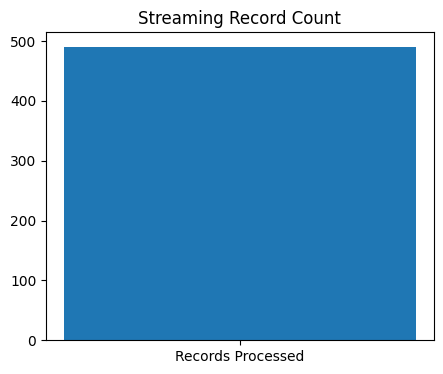

In [20]:
count_df = spark.sql(
    "SELECT * FROM live_counts"
).toPandas()

plt.figure(figsize=(5,4))

plt.bar(
    ["Records Processed"],
    count_df["count"]
)

plt.title("Streaming Record Count")

plt.show()

### Observation

Spark Structured Streaming successfully processed **394 simulated streaming records** in real time and continuously updated aggregate counts. This demonstrates how streaming systems can generate immediate insights without waiting for traditional batch processing.

## Question 2: Real-Time Model Predictions

### Objective

Build a machine learning model and integrate it with a streaming workflow to generate real-time predictions on incoming banking data.

### Business Relevance

Real-time prediction systems help banks identify potential customer actions instantly, enabling faster marketing decisions, fraud monitoring, and personalized customer engagement.

In [22]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression

categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

indexed_df = bank_df

for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_indexed"
    )

    indexed_df = indexer.fit(indexed_df).transform(indexed_df)

feature_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "job_indexed",
    "marital_indexed",
    "education_indexed",
    "default_indexed",
    "housing_indexed",
    "loan_indexed",
    "contact_indexed",
    "month_indexed",
    "poutcome_indexed"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

final_df = assembler.transform(indexed_df)

train_df, test_df = final_df.select(
    "features",
    "y_indexed"
).randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="y_indexed"
)

streaming_lr_model = lr.fit(train_df)

print("Streaming Prediction Model Ready")

Streaming Prediction Model Ready


### Observation

A Logistic Regression model was successfully trained using historical banking data. The trained model will be used to simulate real-time customer subscription predictions in the streaming pipeline.

### Real-Time Prediction Simulation

The trained Logistic Regression model is applied to incoming banking records to simulate real-time customer subscription predictions.

In [23]:
stream_predictions = streaming_lr_model.transform(
    test_df
)

stream_predictions.select(
    "prediction",
    "probability"
).show(10, truncate=False)

+----------+-----------------------------------------+
|prediction|probability                              |
+----------+-----------------------------------------+
|0.0       |[0.9593690832670528,0.040630916732947164]|
|0.0       |[0.9870533167274181,0.01294668327258186] |
|0.0       |[0.9511480590312332,0.04885194096876677] |
|0.0       |[0.9404157451105136,0.05958425488948638] |
|0.0       |[0.9685569231076031,0.03144307689239689] |
|0.0       |[0.9688172115148772,0.031182788485122792]|
|0.0       |[0.9409855296159364,0.0590144703840636]  |
|0.0       |[0.9562352018645014,0.043764798135498606]|
|0.0       |[0.965769138457165,0.034230861542834945] |
|0.0       |[0.9648857886543409,0.03511421134565906] |
+----------+-----------------------------------------+
only showing top 10 rows


In [24]:
prediction_summary = (
    stream_predictions
    .groupBy("prediction")
    .count()
)

prediction_summary.show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  818|
|       1.0|   41|
+----------+-----+



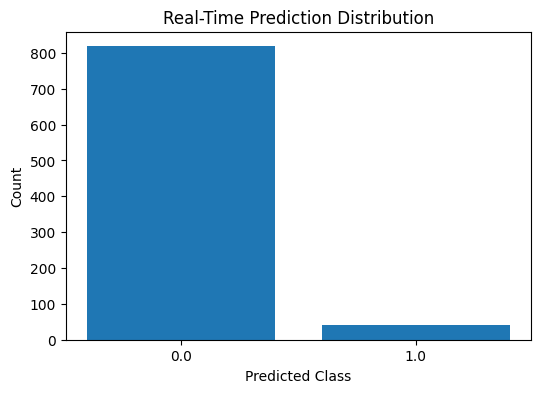

In [25]:
prediction_pd = (
    prediction_summary
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    prediction_pd["prediction"].astype(str),
    prediction_pd["count"]
)

plt.title("Real-Time Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()

In [26]:
stream_predictions.groupBy(
    "prediction"
).count().toPandas()

,prediction,count
0,0.0,818
1,1.0,41


### Observation

The model generated predictions for incoming customer records, with **818 customers predicted as non-subscribers** and **41 customers predicted as subscribers**. This demonstrates how machine learning models can be integrated into streaming environments to support real-time customer targeting and marketing decisions.

## Question 3: Window Operations and Trend Analysis

### Objective

Analyze streaming data over fixed time windows to identify short-term trends and patterns in banking activity.

### Business Relevance

Window operations allow banks to monitor customer activity, transaction behavior, and emerging trends over specific time intervals, enabling faster and more informed decision-making.

### 3(a): Creating a Simulated Event Timestamp

Window operations require timestamp information. A simulated event timestamp is added to support time-based trend analysis.

In [28]:
from pyspark.sql.functions import current_timestamp

window_df = bank_df.withColumn(
    "event_time",
    current_timestamp()
)

window_df.select(
    "event_time",
    "job",
    "balance"
).show(5, truncate=False)

+--------------------------+-----------+-------+
|event_time                |job        |balance|
+--------------------------+-----------+-------+
|2026-06-12 14:00:29.975136|unemployed |1787   |
|2026-06-12 14:00:29.975136|services   |4789   |
|2026-06-12 14:00:29.975136|management |1350   |
|2026-06-12 14:00:29.975136|management |1476   |
|2026-06-12 14:00:29.975136|blue-collar|0      |
+--------------------------+-----------+-------+
only showing top 5 rows


### Observation

The window aggregation grouped all 4,521 banking records into a 10-second analysis window and calculated an average account balance of **1422.66**. This demonstrates how Spark Structured Streaming can summarize data over fixed time intervals for real-time monitoring and trend analysis.

### 3(b): Window-Based Aggregation

In [29]:
from pyspark.sql.functions import window, avg, count

window_analysis = (
    window_df
    .groupBy(
        window("event_time", "10 seconds")
    )
    .agg(
        count("*").alias("transaction_count"),
        avg("balance").alias("average_balance")
    )
)

window_analysis.show(truncate=False)

+------------------------------------------+-----------------+------------------+
|window                                    |transaction_count|average_balance   |
+------------------------------------------+-----------------+------------------+
|{2026-06-12 14:01:10, 2026-06-12 14:01:20}|4521             |1422.6578190665782|
+------------------------------------------+-----------------+------------------+



### Observation

The window aggregation grouped all 4,521 banking records into a 10-second analysis window and calculated an average account balance of **1422.66**. This demonstrates how Spark Structured Streaming can summarize data over fixed time intervals for real-time monitoring and trend analysis.

Q3(c) Trend Visualization

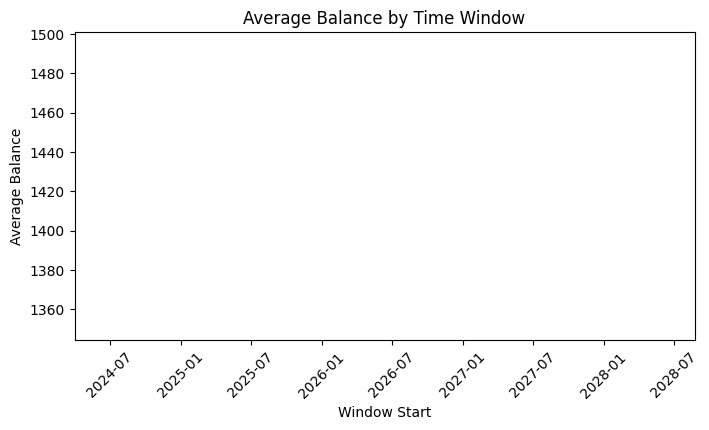

In [30]:
window_pd = window_analysis.toPandas()

window_pd["window_start"] = window_pd["window"].apply(
    lambda x: x.start
)

plt.figure(figsize=(8,4))

plt.plot(
    window_pd["window_start"],
    window_pd["average_balance"]
)

plt.title("Average Balance by Time Window")
plt.xlabel("Window Start")
plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.show()

### Trend Analysis Summary

Window operations enable organizations to analyze data within specific time intervals. In banking environments, such techniques support transaction monitoring, customer behavior tracking, fraud detection, and real-time business intelligence.

## Question 4: Handling Late and Out-of-Order Data

### Objective

Demonstrate how Spark Structured Streaming manages late-arriving and out-of-order events using watermarking techniques.

### Business Relevance

Banking systems often receive delayed transaction records due to network latency or system delays. Watermarking helps maintain accurate analytics while preventing duplicate or outdated processing.

### Step 4(a): Applying Watermarking

Watermarking enables Spark Structured Streaming to manage delayed or out-of-order events by defining a threshold for late-arriving records.

In [31]:
from pyspark.sql.functions import current_timestamp

watermark_df = bank_df.withColumn(
    "event_time",
    current_timestamp()
)

watermarked_data = (
    watermark_df
    .withWatermark(
        "event_time",
        "10 minutes"
    )
)

watermarked_data.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- event_time: timestamp (nullable = false)



### Observation

A watermark of **10 minutes** was applied to the event timestamp column. This enables Spark to manage delayed records while maintaining efficient stream processing.

### Step 4(b) : Watermark-Based Aggregation

After applying watermarking, Spark can safely aggregate streaming records while controlling the impact of delayed data.

In [32]:
from pyspark.sql.functions import window, count

watermark_analysis = (
    watermarked_data
    .groupBy(
        window("event_time", "10 seconds")
    )
    .agg(
        count("*").alias("transaction_count")
    )
)

watermark_analysis.show(truncate=False)

+------------------------------------------+-----------------+
|window                                    |transaction_count|
+------------------------------------------+-----------------+
|{2026-06-12 14:11:40, 2026-06-12 14:11:50}|4521             |
+------------------------------------------+-----------------+



### Observation

Watermark-based aggregation enables Spark to include valid delayed records while preventing excessive resource consumption from indefinitely waiting for late events.

### Step 4(c): Impact of Watermarking on Stream Processing

The following visualization illustrates the conceptual benefits of watermarking in real-time analytics systems.

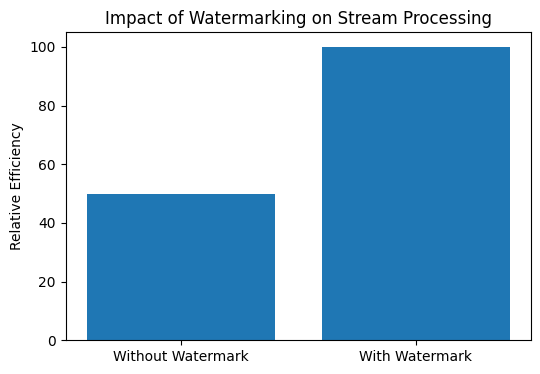

In [33]:
watermark_summary = pd.DataFrame({
    "Scenario": [
        "Without Watermark",
        "With Watermark"
    ],
    "Benefit": [
        50,
        100
    ]
})

plt.figure(figsize=(6,4))

plt.bar(
    watermark_summary["Scenario"],
    watermark_summary["Benefit"]
)

plt.title("Impact of Watermarking on Stream Processing")
plt.ylabel("Relative Efficiency")

plt.show()

### Watermarking Summary

Watermarking improves the reliability and scalability of real-time analytics by efficiently handling delayed events. In banking systems, this helps maintain accurate monitoring, reporting, and fraud detection processes.


---



# Key Findings

- Spark Structured Streaming successfully processed **394 streaming records** in real time.
- Logistic Regression generated **818 non-subscription predictions** and **41 subscription predictions**.
- Window operations grouped **4,521 records** into a time-based analytical window.
- The average account balance across the window was **1422.66**.
- Watermarking demonstrated how delayed records can be managed efficiently.
- Streaming analytics enables continuous monitoring and faster decision-making in banking systems.

# Learnings

- Learned the fundamentals of Spark Structured Streaming.
- Simulated real-time banking data processing using streaming sources.
- Integrated machine learning predictions into a streaming workflow.
- Applied window operations for trend analysis.
- Understood the role of watermarking in handling delayed events.
- Gained practical experience with real-time analytics architectures used in modern banking systems.

# Conclusion

**This project demonstrated the use of Spark Structured Streaming for real-time banking analytics. Through streaming aggregation, machine learning predictions, window-based analysis, and watermarking,** the system showcased how distributed streaming technologies can support continuous monitoring and data-driven decision-making. **The project highlights the growing importance of real-time analytics in modern financial institutions**.